# Find Optimal K for NMF
Find the optimal number of topics (K) for NMF using **Reconstruction Error** and **Topic Coherence (Cᵥ)** with spaCy preprocessing.

## 1. Installation
Run this cell once to install all required dependencies. You can skip it if they are already installed.

In [1]:
import sys

!{sys.executable} -m pip install \
    notebook \
    ipywidgets \
    numpy \
    matplotlib \
    tqdm \
    scikit-learn \
    spacy \
    gensim

# Download the spaCy English model
!{sys.executable} -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Imports

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
import spacy
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration
Set your input file path and K search range here.

In [2]:
INPUT_FILE = '/content/drive/MyDrive/ColabData/dataset_comsci_math.json' # Path to your JSON dataset file
START_K    = 2 # Starting value for K (min 2)
END_K      = 30 # Ending value for K
STEP_K     = 1 # Step size for K
OUTPUT_DIR = '/content/drive/MyDrive/ColabData/' # Directory to save the output plot

## 4. Load Data

In [3]:
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"File '{INPUT_FILE}' does not exist.")

print(f"Loading data from {INPUT_FILE}...")
with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

texts = [item.get('text', '') for item in data if item.get('text', '').strip()]

if not texts:
    raise ValueError("No text data found in the dataset.")

print(f"Loaded {len(texts)} documents.")

Loading data from /content/drive/MyDrive/ColabData/dataset_comsci_math.json...
Loaded 266 documents.


## 5. spaCy Setup & Custom Stop Words

In [4]:
print("Loading spaCy 'en_core_web_sm'...")
# If not installed, run: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

academic_stopwords = [
    'finding', 'findings', 'illustrate', 'significant', 'provide', 'provides', 'potential', 'associated', 'effective', 'aspect', 'aspects', 'challenge', 'challenges',
    'paper', 'study', 'research', 'result', 'results', 'method', 'methodology',
    'proposed', 'propose', 'approach', 'based', 'using', 'used', 'use', 'to', 'we', 'source',
    'analysis', 'model', 'system', 'data', 'application', 'new', 'development',
    'performance', 'conclusion', 'abstract', 'introduction', 'work', 'time',
    'significant', 'shown', 'show', 'demonstrate', 'experiment', 'experimental',
    'university', 'department', 'author', 'et', 'al', 'figure', 'table',
    'high', 'low', 'large', 'small', 'different', 'various', 'property', 'properties', 'increase', 'effect', 'activity',
    'structure', 'compound', 'condition', 'quality', 'entry', 'contain', 'parameter', 'observe', 'report', 'present', 'evaluate'
]

for word in academic_stopwords:
    nlp.vocab[word].is_stop = True

print(f"Added {len(academic_stopwords)} academic stop words.")

custom_stopwords = list(set(list(ENGLISH_STOP_WORDS) + academic_stopwords))

def spacy_tokenizer(text):
    if not text:
        return []
    doc = nlp(text)
    return [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num
        and len(token) > 2
    ]

Loading spaCy 'en_core_web_sm'...
Added 78 academic stop words.


## 6. Vectorize with TF-IDF (sklearn)

In [6]:
print("Fitting TF-IDF Vectorizer with spaCy tokenizer...")
vectorizer = TfidfVectorizer(stop_words=custom_stopwords ,tokenizer=spacy_tokenizer, max_df=0.7, min_df=5)
tfidf_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print(f"Vocabulary size      : {len(feature_names)}")
print(f"TF-IDF matrix shape  : {tfidf_matrix.shape}")

Fitting TF-IDF Vectorizer with spaCy tokenizer...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vocabulary size      : 625
TF-IDF matrix shape  : (266, 625)


## 7. Tokenize Texts for Gensim Coherence Model

In [7]:
print("Tokenizing texts for Gensim (this may take a while)...")
tokenized_texts = [spacy_tokenizer(text) for text in tqdm(texts, desc="Tokenizing")]
dictionary = Dictionary(tokenized_texts)
print(f"Gensim dictionary size: {len(dictionary)}")

Tokenizing texts for Gensim (this may take a while)...


Tokenizing:   0%|          | 0/266 [00:00<?, ?it/s]

Gensim dictionary size: 3372


## 8. Grid Search over K

In [8]:
start_k = max(2, START_K)
k_values = list(range(start_k, END_K + 1, STEP_K))
reconstruction_errors = []
coherence_scores      = []

print(f"Starting grid search for K = {k_values}")

for k in tqdm(k_values, desc="Tuning NMF"):
    # Fit NMF
    nmf_model = NMF(n_components=k, random_state=42, max_iter=500)
    nmf_model.fit(tfidf_matrix)

    # Reconstruction Error
    reconstruction_errors.append(nmf_model.reconstruction_err_)

    # Top-10 words per topic
    top_words_per_topic = []
    for topic in nmf_model.components_:
        top_features_ind = topic.argsort()[:-10 - 1:-1]
        top_words_per_topic.append([feature_names[i] for i in top_features_ind])

    # Topic Coherence (Cᵥ)
    cm = CoherenceModel(
        topics=top_words_per_topic,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_scores.append(cm.get_coherence())

print("Grid search complete.")

Starting grid search for K = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


Tuning NMF:   0%|          | 0/29 [00:00<?, ?it/s]

Grid search complete.


## 9. Results Summary

In [9]:
best_coherence_k = k_values[int(np.argmax(coherence_scores))]
best_recon_k     = k_values[int(np.argmin(reconstruction_errors))]

print(f"{'K':>5} | {'Recon. Error':>14} | {'Coherence (Cᵥ)':>15}")
print("-" * 40)
for k, r, c in zip(k_values, reconstruction_errors, coherence_scores):
    print(f"{k:>5} | {r:>14.4f} | {c:>15.4f}")

print(f"\nBest K by Coherence          : {best_coherence_k}")
print(f"Best K by Reconstruction Error: {best_recon_k}")

    K |   Recon. Error |  Coherence (Cᵥ)
----------------------------------------
    2 |        15.3503 |          0.7147
    3 |        15.1443 |          0.6238
    4 |        14.9915 |          0.6382
    5 |        14.8471 |          0.5661
    6 |        14.6983 |          0.6040
    7 |        14.5596 |          0.5635
    8 |        14.4333 |          0.5490
    9 |        14.3127 |          0.5652
   10 |        14.1945 |          0.5461
   11 |        14.0749 |          0.5281
   12 |        13.9612 |          0.5201
   13 |        13.8514 |          0.5258
   14 |        13.7515 |          0.5263
   15 |        13.6487 |          0.5437
   16 |        13.5517 |          0.5330
   17 |        13.4633 |          0.5327
   18 |        13.3614 |          0.5317
   19 |        13.2630 |          0.5246
   20 |        13.1790 |          0.5307
   21 |        13.1042 |          0.5182
   22 |        13.0190 |          0.5063
   23 |        12.9214 |          0.5176
   24 |        1

## 10. Plot: Reconstruction Error vs Topic Coherence

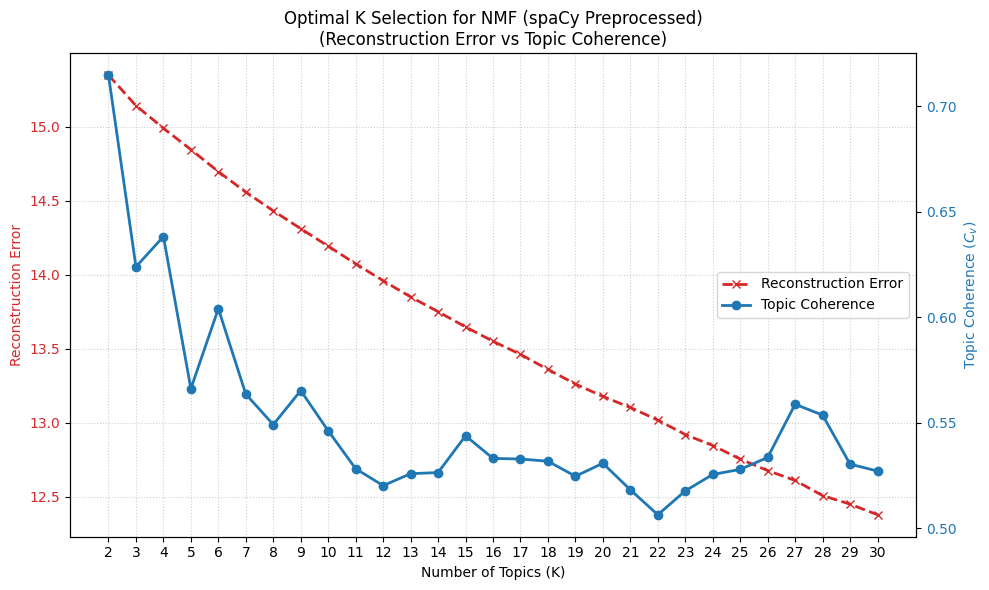

Plot saved to: /content/drive/MyDrive/ColabData/nmf_optimal_k_selection.png


In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Reconstruction Error (left axis)
color_recon = 'tab:red'
ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Reconstruction Error', color=color_recon)
ax1.plot(k_values, reconstruction_errors, marker='x', color=color_recon,
         linestyle='--', linewidth=2, label='Reconstruction Error')
ax1.tick_params(axis='y', labelcolor=color_recon)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle=':', alpha=0.6)

# Coherence (right axis)
color_coh = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_ylabel('Topic Coherence ($C_v$)', color=color_coh)
ax2.plot(k_values, coherence_scores, marker='o', color=color_coh,
         linewidth=2, label='Topic Coherence')
ax2.tick_params(axis='y', labelcolor=color_coh)

plt.title('Optimal K Selection for NMF (spaCy Preprocessed)\n(Reconstruction Error vs Topic Coherence)')
fig.tight_layout()

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

output_path = os.path.join(OUTPUT_DIR, 'nmf_optimal_k_selection.png')
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_path}")